## Example of using Dynamo in Python

Example: Load a Dynamo file, then plot trees in 2D and 3D

In [11]:

# Dynamo code:
import pydynamo_brain.analysis as pdAnalysis
import pydynamo_brain.model as pdModel
import pydynamo_brain.files as pdFiles
import pydynamo_brain.util as pdUtil



In [12]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D 
import copy
import numpy as np


In [13]:
%matplotlib inline
# Change output figure size
plt.rcParams['figure.figsize'] = [10, 10]
plt.rcParams["figure.facecolor"] = "white"


# Part 1: Load Dynamo


In [14]:
dynamoPath = "ExampleNeuron.dyn.gz"


In [15]:


fullState = pdFiles.loadState(dynamoPath)

print("%d volumes loaded" % (len(fullState.trees)))


11 volumes loaded


# Part 2: Plotting Trees


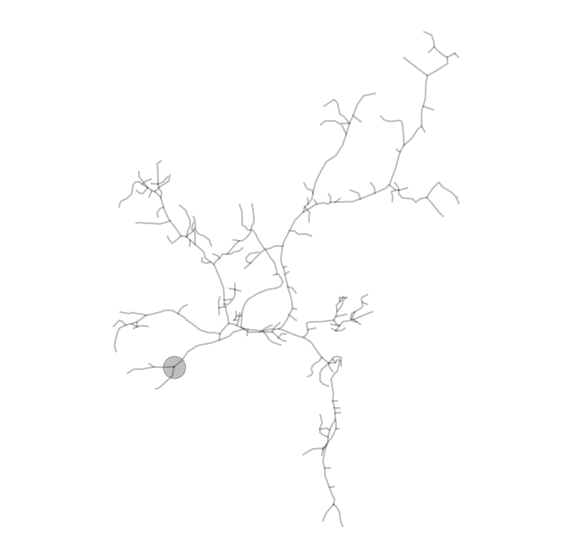

In [16]:
def plot2DTrees(fullstate, treeIdx,  alpha=0.25, linewidth=1.75):
    """
    Plot a Dynamo Tree in 3D using pixel-space coordinates (x, y, z).

    Parameters
    ----------
    fullState : FullState
    treeIdx   : int
        Index of the tree in fullState.trees.
    ax        : matplotlib 3D axis (optional)
    color     : str or tuple
    alpha     : float
    linewidth : float
    """
    fig, axs = plt.subplots(1,1)

    axs.axis('equal')
    axs.axis('off')
    branchIDs = pdUtil.sortedBranchIDList(fullState.trees)
    # Plot a large point for the soma location
    plt.scatter(fullState.trees[treeIdx].getPointByID('00000000').location[0],
                fullState.trees[treeIdx].getPointByID('00000000').location[1], s=500, c='black', alpha=alpha)

    for branch in branchIDs:
        x = []
        y = []
        if fullState.trees[treeIdx].getBranchByID(branch) is not None:
            for j, point in enumerate(fullState.trees[treeIdx].getBranchByID(branch).points):
                if j == 0:
                    x.append(point.nextPointInBranch(-1).location[0])
                    y.append(point.nextPointInBranch(-1).location[1])
                x.append(point.location[0])
                y.append(point.location[1])
            axs.plot(x,y, c='black', alpha=.25, linewidth=1.75)
plot2DTrees(fullState, 0)

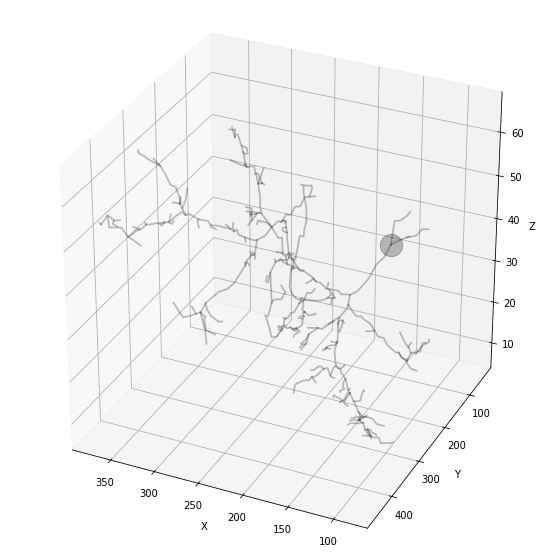

In [17]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection

def plot3DTrees(fullState, treeIdx, color='black', alpha=0.25, linewidth=1.75):
    """
    Plot a Dynamo Tree in 3D using pixel-space coordinates (x, y, z).

    Parameters
    ----------
    fullState : FullState
    treeIdx   : int
        Index of the tree in fullState.trees.
    color     : str or tuple
        Line color for branches.
    alpha     : float
        Line transparency.
    linewidth : float
        Line thickness.
    """
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(fullState.trees[treeIdx].getPointByID('00000000').location[0],
                fullState.trees[treeIdx].getPointByID('00000000').location[1],
                fullState.trees[treeIdx].getPointByID('00000000').location[2], s=500, c='black', alpha=alpha)
    branchIDs = pdUtil.sortedBranchIDList(fullState.trees)
    for branch in branchIDs:
        branch_obj = fullState.trees[treeIdx].getBranchByID(branch)
        if branch_obj is not None:
            xs, ys, zs = [], [], []
            for j, point in enumerate(branch_obj.points):
                # include previous point if available
                if j == 0:
                    prev = point.nextPointInBranch(-1)
                    if prev:
                        x0, y0, z0 = prev.location
                        xs.append(x0)
                        ys.append(y0)
                        zs.append(z0)
                x, y, z = point.location
                xs.append(x)
                ys.append(y)
                zs.append(z)
            ax.plot(xs, ys, zs, c=color, alpha=alpha, linewidth=linewidth)

    # clean look
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_box_aspect([1, 1, 1])  # equal aspect
    ax.view_init(elev=30, azim=115)
    plt.show()
plot3DTrees(fullState, 0)

# Part 3: Using tree methods to reparent branches
The methods updateAllPrimaryBranches() and updateAllBranchesMinimalAngle() change how branches are connected

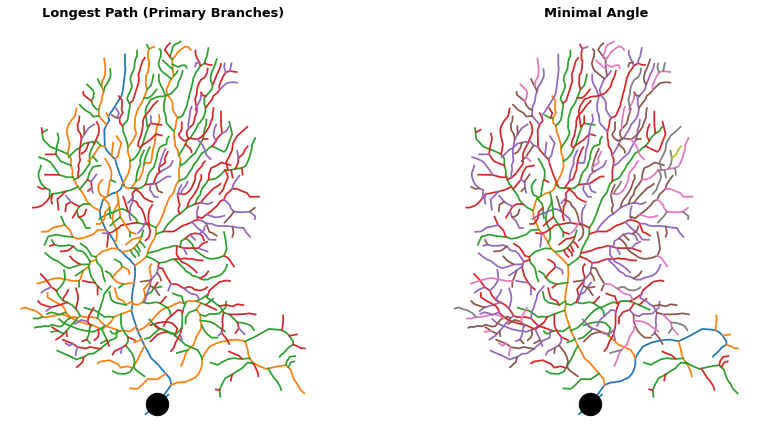

In [18]:
import copy
import matplotlib.pyplot as plt
from matplotlib import cm

def plot_branch_order_comparison(fullState, tree_idx=0, soma_id="00000000",
                                 savepath="BranchOrder_Comparison.svg",
                                 linewidth=1.75):
    """
    Make a 2-panel comparison of branch order coloring:
      Left  : updateAllPrimaryBranches (longest path continuation)
      Right : updateAllBranchesMinimalAngle (minimal-angle continuation)
    """
    # Safely get branch IDs once
    try:
        branchIDs = pdUtil.sortedBranchIDList(fullState.trees)
    except TypeError:
        branchIDs = pdUtil.sortedBranchIDList(fullState.trees[tree_idx])

    # Clone the tree so panels start from the same baseline
    treeA = copy.deepcopy(fullState.trees[tree_idx])
    treeB = copy.deepcopy(fullState.trees[tree_idx])

    # Apply each normalization to its own copy
    treeA.updateAllPrimaryBranches()
    treeB.updateAllBranchesMinimalAngle()

    # Set up figure
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
    titles = ["Longest Path (Primary Branches)", "Minimal Angle"]
    trees = [treeA, treeB]
    cmap = cm.get_cmap("tab10")

    for ax, tree, title in zip(axes, trees, titles):
        ax.set_aspect("equal", adjustable="box")
        ax.axis("off")

        # Soma
        soma_pt = tree.getPointByID(soma_id)
        if soma_pt is not None:
            ax.scatter(soma_pt.location[0], soma_pt.location[1], s=500, c="black", zorder=5)

        # Branches colored by order
        for bid in branchIDs:
            branch = tree.getBranchByID(bid)
            if branch is None:
                continue

            xs, ys = [], []
            pts = getattr(branch, "points", [])
            if not pts:
                continue

            # connect to previous point if available
            prev = pts[0].nextPointInBranch(-1)
            if prev is not None:
                xs.append(prev.location[0]); ys.append(prev.location[1])

            for p in pts:
                xs.append(p.location[0]); ys.append(p.location[1])

            order = branch.getOrder()
            ax.plot(xs, ys, c=cmap(order - 1), linewidth=linewidth)

        ax.set_title(title, fontsize=13, weight="bold")

    return fig, axes

# Example:
dynamoPath = "Supplemental_Neuron.dyn.gz"
fullState = pdFiles.loadState(dynamoPath)
fig, axes = plot_branch_order_comparison(fullState, tree_idx=0, soma_id="00000000",
                                          savepath="BranchOrder_Comparison.svg")


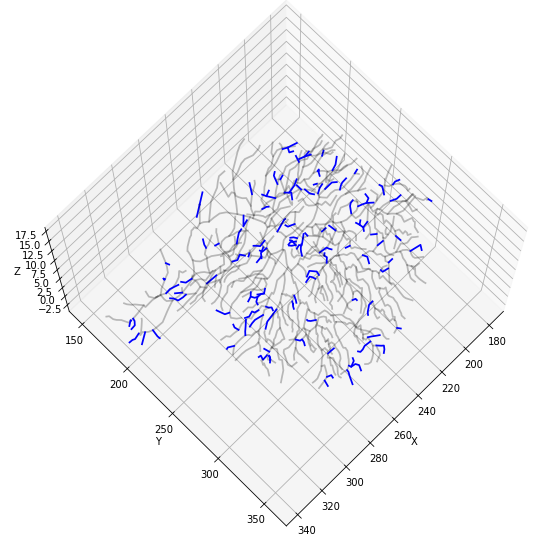

111 branches below the length threshold 10


In [19]:

def plot3DTrees_CountShortBranches(fullState, treeIdx, color='black', alpha=0.25, linewidth=1.75, threshold=10):
    """
    Plot a Dynamo Tree in 3D using pixel-space coordinates (x, y, z). Color short branches blue

    Parameters
    ----------
    fullState : FullState
    treeIdx   : int
        Index of the tree in fullState.trees.
    color     : str or tuple
        Line color for branches.
    alpha     : float
        Line transparency.
    linewidth : float
        Line thickness.
    threshold: float
        lenght in um for short branches
    """
    short = 0
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    branchIDs = pdUtil.sortedBranchIDList(fullState.trees)
    _color, _alpha = copy.copy(color), copy.copy(alpha)
    for branch in branchIDs:
        branch_obj = fullState.trees[treeIdx].getBranchByID(branch)
        branch_color = color
        branch_alpha = alpha
        if branch_obj is not None:
            # Plot a blue branch if it is shorter than a threshold 
            if branch_obj.worldLengths()[0] < threshold:
                short += 1
                branch_color = 'blue'
                branch_alpha = 1
            xs, ys, zs = [], [], []
            for j, point in enumerate(branch_obj.points):
                # include previous point if available
                if j == 0:
                    prev = point.nextPointInBranch(-1)
                    if prev:
                        x0, y0, z0 = prev.location
                        xs.append(x0)
                        ys.append(y0)
                        zs.append(z0)
                x, y, z = point.location
                xs.append(x)
                ys.append(y)
                zs.append(z)
            ax.plot(xs, ys, zs, c=branch_color, alpha=branch_alpha, linewidth=linewidth)
     
            
    # clean look
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_box_aspect([1, 1, 1])  # equal aspect
    ax.view_init(elev=75, azim=45)
    plt.show()
    print(short, "branches below the length threshold", threshold)
plot3DTrees_CountShortBranches(fullState, 0)